# 獨立 Downstream Spatial Simulation

這份 notebook 使用**全新模擬資料**驗證已訓練完成的 NN、空間 GP 選模與 return-level 流程。NN 權重全程固定，不重新訓練，也不使用 TCCIP 真實資料作為模擬真值。

已知真值為：

$$
\mu(s),\qquad \log\sigma(s),\qquad \xi(s).
$$

每個格點由已知 GEV 分布產生 45 個 annual maxima，再經過：

$$
\text{annual maxima}\rightarrow\text{11 quantiles}\rightarrow\text{frozen NN}\rightarrow\text{nested buffered spatial CV}\rightarrow\text{GP}\rightarrow RL_{50},RL_{100}.
$$


## 1. 為什麼需要這個模擬？

真實 TCCIP 資料沒有可直接觀察的 GEV 真實參數或真實 return level。真實資料的 Spatial-CV RMSE 主要回答 GP 能否重建 NN-derived 空間曲面；本模擬因為知道真值，所以能回答整條 NN--GP 流程是否估對。

本分析分開報告三種資訊：

1. Frozen NN 對已知真值的誤差。
2. Nested OOF GP 對已知真值的誤差。
3. GP 對 NN 曲面的重建誤差。

最終 return-level 誤差使用：

$$
RMSE_T=\sqrt{\frac{1}{N}\sum_{i=1}^{N}\left(\widehat{RL}_{T,i}-RL^{true}_{T,i}\right)^2}.
$$


In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
repo = cwd if (cwd / 'src').exists() else cwd.parent
sys.path.insert(0, str(repo / 'src'))

from downstream_spatial_simulation import (
    SCENARIOS,
    SimulationConfig,
    generate_true_parameters,
    make_grid,
    plot_first_replicate_surfaces,
    plot_return_level_surfaces,
    run_monte_carlo,
    save_results,
    summarize_monte_carlo,
)


## 2. 三個預先指定的資料生成情境

- `stationary_rbf`：平穩、無方向性的 RBF covariance。
- `stationary_matern`：平穩、無方向性的 Matérn covariance，真實平滑度為 $\nu=1.5$。
- `elevation_anisotropic_matern`：加入已知 elevation mean effect，並使用方向相依的 Matérn covariance。

第三個情境用來檢查選模流程能否同時辨認高程平均結構與 anisotropy。$\xi$ 被限制在合理區間，避免不穩定的 return-level 真值。


In [2]:
preview_config = SimulationConfig(grid_side=20, n_replicates=1)
preview_grid = make_grid(preview_config)
preview_truth = generate_true_parameters(
    preview_grid,
    scenario='elevation_anisotropic_matern',
    rng=__import__('numpy').random.default_rng(preview_config.seed),
)
preview_truth.describe().T


,count,mean,std,min,25%,50%,75%,max
cell_id,400.0,199.500000,115.614301,0.000000,99.750000,199.500000,299.250000,399.000000
x_km,400.0,95.000000,57.735027,0.000000,47.500000,95.000000,142.500000,190.000000
y_km,400.0,95.000000,57.735027,0.000000,47.500000,95.000000,142.500000,190.000000
elevation_m,400.0,855.224847,988.238316,0.000000,0.000000,365.025198,1617.828367,3182.181594
mu_true,400.0,30.417497,3.047451,22.725120,28.302507,31.291206,32.299604,36.577238
log_sigma_true,400.0,0.484359,0.109587,0.275796,0.395270,0.468480,0.552462,0.782824
xi_true,400.0,0.045208,0.019906,-0.002548,0.030057,0.044214,0.062234,0.096196
RL50_true,400.0,37.396665,2.942911,29.751376,35.723863,37.688199,39.032765,44.567375
RL100_true,400.0,38.784827,2.971932,31.179428,37.199568,38.950467,40.351517,46.560403


## 3. Nested buffered spatial cross-validation

外層 spatial folds 只用來估計最終泛化誤差；內層 buffered spatial CV 才能選擇 trend、kernel 與 isotropic/anisotropic covariance。這可避免同一批 test GRID 同時參與選模與成效評估。

候選模型為：

$$
T_0:\ y(s)=\beta_0+w(s)+\epsilon(s),
$$

$$
T_1:\ y(s)=\beta_0+\beta_1\operatorname{Elevation}(s)+w(s)+\epsilon(s).
$$

每種 trend 分別搭配 isotropic RBF、isotropic Matérn $\nu=1.5$ 與 anisotropic Matérn $\nu=1.5$。


## 4. Pilot 設定

Exact GP 的計算量較大，因此 `max_train=200` 是每次 fit 的 training cap；它不會改變 test fold。`n_jobs=-2` 表示使用全部邏輯 CPU 核心減一，並以 replicate 為單位平行運算。每完成一次模擬，輸出會顯示 `已完成 x/總數`。


In [3]:
pilot_config = SimulationConfig(
    grid_side=20,
    spacing_km=10.0,
    n_years=45,
    outer_folds=5,
    inner_folds=3,
    buffer_km=20.0,
    max_train=200,
    min_train=20,
    n_replicates=200,
    seed=20260801,
    n_restarts_optimizer=0,
    n_jobs=-2,              # 跑核心數減一
)
pilot_config


SimulationConfig(grid_side=20, spacing_km=10.0, n_years=45, outer_folds=5, inner_folds=3, buffer_km=20.0, max_train=200, min_train=20, n_replicates=200, seed=20260801, n_restarts_optimizer=0, n_jobs=-2)

In [4]:
results = run_monte_carlo(
    config=pilot_config,
    scenarios=SCENARIOS,
)


開始 Monte Carlo：共 600 次模擬，使用 11 個 CPU worker。
已完成 1/600：stationary_rbf，replicate 7/200
已完成 2/600：stationary_rbf，replicate 3/200
已完成 3/600：stationary_rbf，replicate 11/200
已完成 4/600：stationary_rbf，replicate 1/200
已完成 5/600：stationary_rbf，replicate 4/200
已完成 6/600：stationary_rbf，replicate 5/200
已完成 7/600：stationary_rbf，replicate 10/200
已完成 8/600：stationary_rbf，replicate 6/200
已完成 9/600：stationary_rbf，replicate 2/200
已完成 10/600：stationary_rbf，replicate 9/200
已完成 11/600：stationary_rbf，replicate 8/200
已完成 12/600：stationary_rbf，replicate 14/200
已完成 13/600：stationary_rbf，replicate 12/200
已完成 14/600：stationary_rbf，replicate 15/200
已完成 15/600：stationary_rbf，replicate 18/200
已完成 16/600：stationary_rbf，replicate 17/200
已完成 17/600：stationary_rbf，replicate 21/200
已完成 18/600：stationary_rbf，replicate 13/200
已完成 19/600：stationary_rbf，replicate 22/200
已完成 20/600：stationary_rbf，replicate 19/200
已完成 21/600：stationary_rbf，replicate 20/200
已完成 22/600：stationary_rbf，replicate 16/200
已完成 23/600：stationary_rbf，r

## 5. 參數與 return-level 恢復結果

`NN` 列評估 frozen NN 本身；`NN_plus_GP_OOF` 評估完整流程；`GP_reconstruction_of_NN` 只回答 GP 能否重建 NN 曲面，不能當成對真值的準確度。

判讀時應同時檢查平均 RMSE、replicate 間標準差、bias，以及 $RL_{50}$、$RL_{100}$ 是否因 $\xi$ 誤差而明顯惡化。


In [5]:
metric_summary, selection_frequency = summarize_monte_carlo(results)
metric_summary.sort_values(['scenario', 'outcome', 'stage'])


,scenario,outcome,stage,mean_RMSE,sd_RMSE,mean_MAE,mean_Bias
0,elevation_anisotropic_matern,RL100,NN,3.089027,0.369840,2.341027,0.128129
1,elevation_anisotropic_matern,RL100,NN_plus_GP_OOF,1.488081,0.271676,1.188403,-0.510670
2,elevation_anisotropic_matern,RL50,NN,2.127251,0.228934,1.666964,-0.073650
3,elevation_anisotropic_matern,RL50,NN_plus_GP_OOF,1.325912,0.235437,1.057508,-0.465501
4,elevation_anisotropic_matern,log_sigma,GP_reconstruction_of_NN,0.185216,0.017487,0.148171,0.003099
5,elevation_anisotropic_matern,log_sigma,NN,0.182878,0.007329,0.146413,-0.112359
6,elevation_anisotropic_matern,log_sigma,NN_plus_GP_OOF,0.158382,0.021402,0.131957,-0.109260
7,elevation_anisotropic_matern,mu,GP_reconstruction_of_NN,0.948549,0.171597,0.750376,-0.000032
8,elevation_anisotropic_matern,mu,NN,0.264328,0.019281,0.208176,0.008978
9,elevation_anisotropic_matern,mu,NN_plus_GP_OOF,0.908784,0.177918,0.717205,0.008947


## 6. Kernel、trend 與 anisotropy 的選取頻率

不是只看單次是否選中，而是跨 outer folds 與 Monte Carlo replicates 計算 selection rate。若真實 RBF 情境經常選到 RBF、真實 Matérn 情境經常選到 Matérn，才表示流程具有 kernel identification 能力。

第三情境中，$\mu$ 與 $\log\sigma$ 應較常選到 $T_1$；但不能預設每個參數都必須加入高程。


In [6]:
selection_frequency.sort_values(
    ['scenario', 'target', 'selection_rate'],
    ascending=[True, True, False],
)


,scenario,target,selected_model,selection_count,selection_rate
3,elevation_anisotropic_matern,log_sigma,T1_Matern15_anisotropic,462,0.462
5,elevation_anisotropic_matern,log_sigma,T1_RBF_isotropic,182,0.182
4,elevation_anisotropic_matern,log_sigma,T1_Matern15_isotropic,175,0.175
0,elevation_anisotropic_matern,log_sigma,T0_Matern15_anisotropic,77,0.077
1,elevation_anisotropic_matern,log_sigma,T0_Matern15_isotropic,63,0.063
2,elevation_anisotropic_matern,log_sigma,T0_RBF_isotropic,41,0.041
6,elevation_anisotropic_matern,mu,T1_Matern15_anisotropic,670,0.670
7,elevation_anisotropic_matern,mu,T1_Matern15_isotropic,202,0.202
8,elevation_anisotropic_matern,mu,T1_RBF_isotropic,128,0.128
9,elevation_anisotropic_matern,xi,T0_Matern15_anisotropic,288,0.288


## 7. 第一個 replicate 的空間曲面

圖中並列 known truth、frozen NN 與 nested OOF GP。OOF 圖的每一個格點都來自沒有使用該 outer test fold 的模型，不能用 full-data fitted surface 取代。


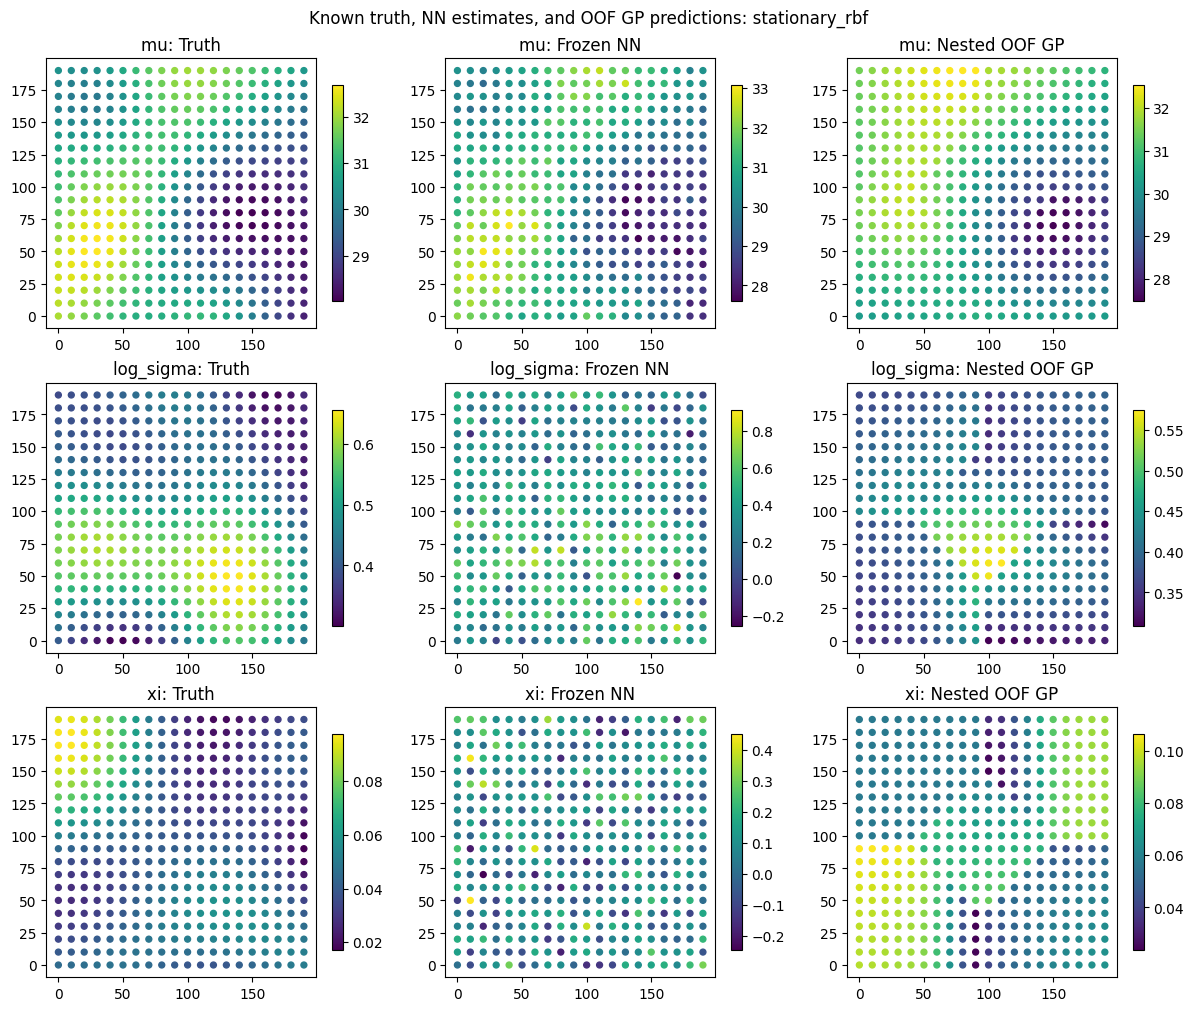

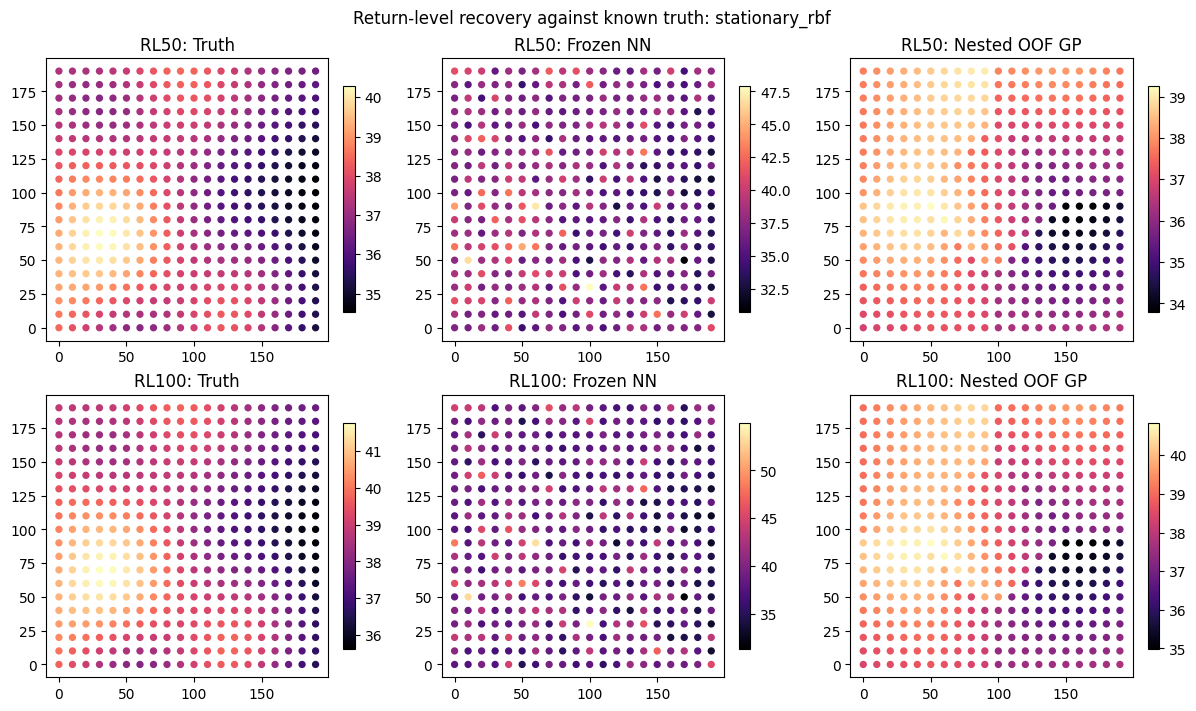

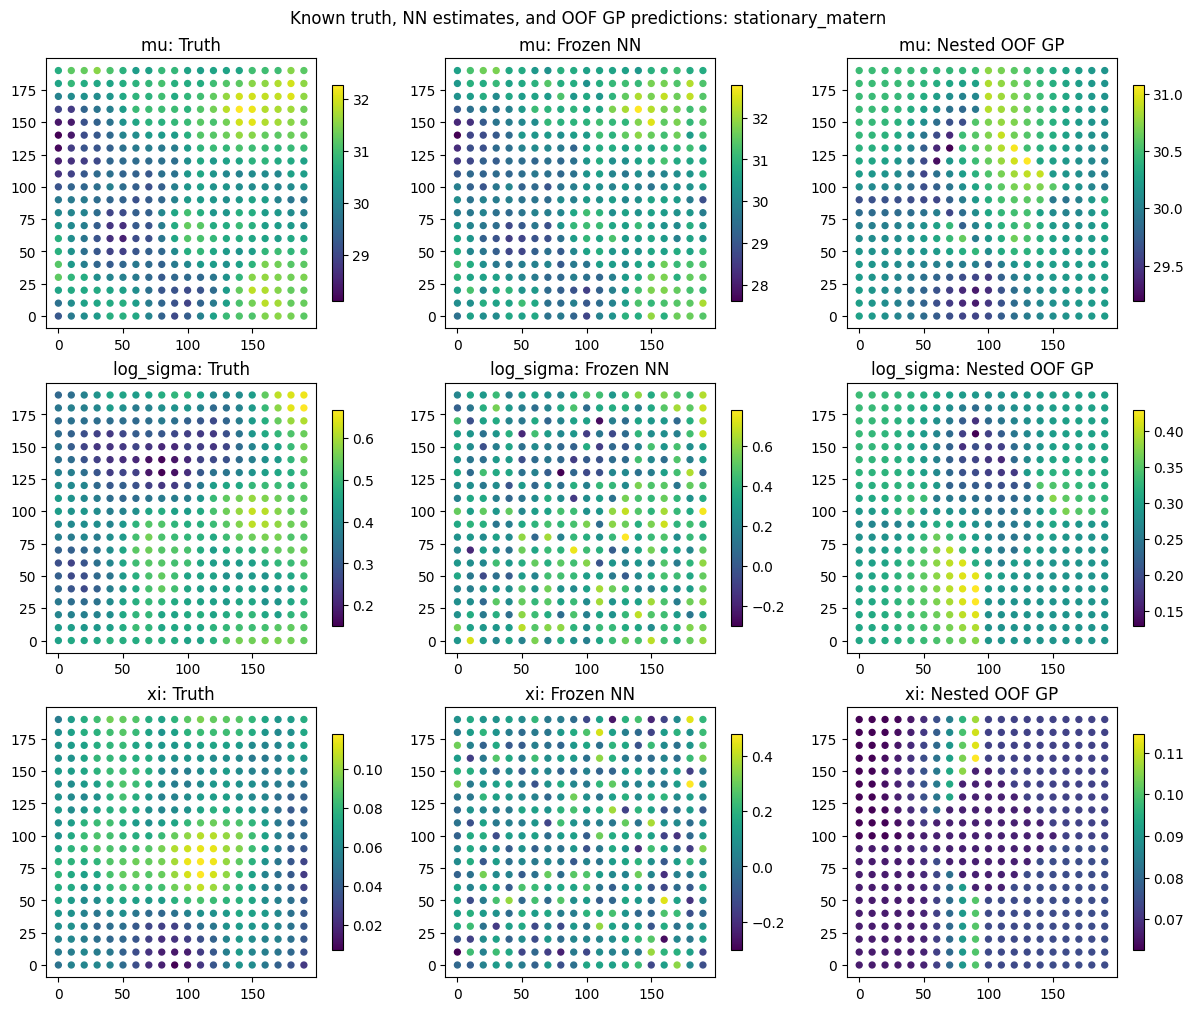

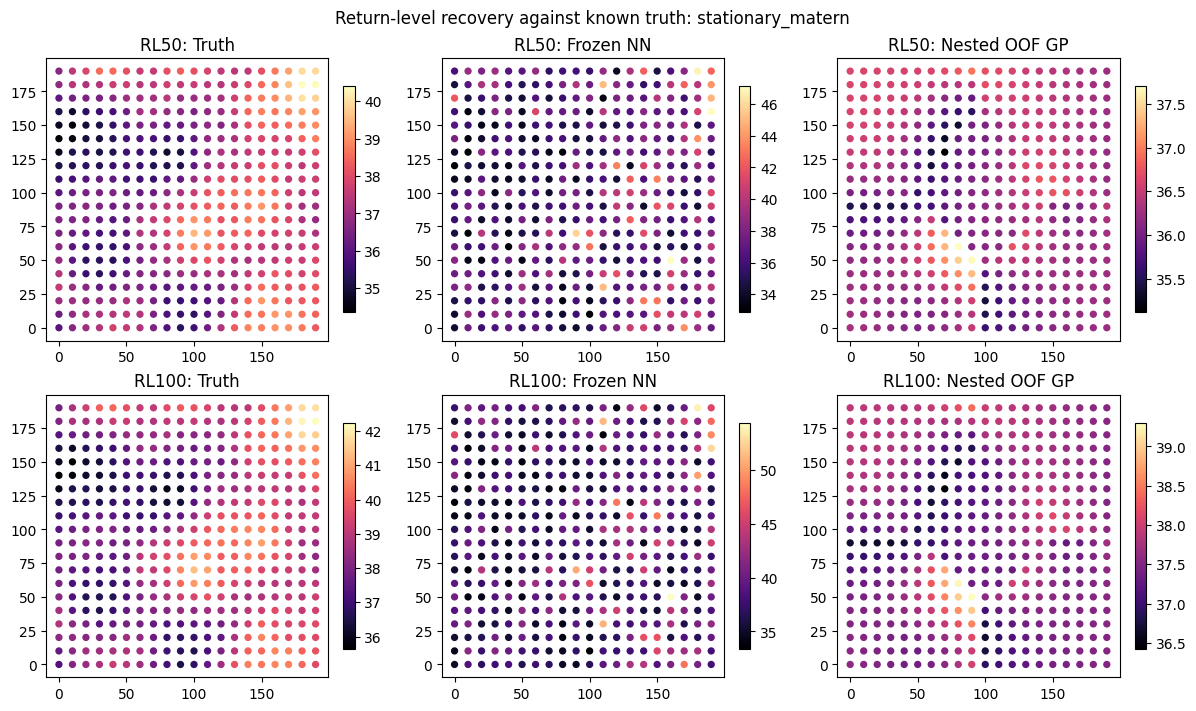

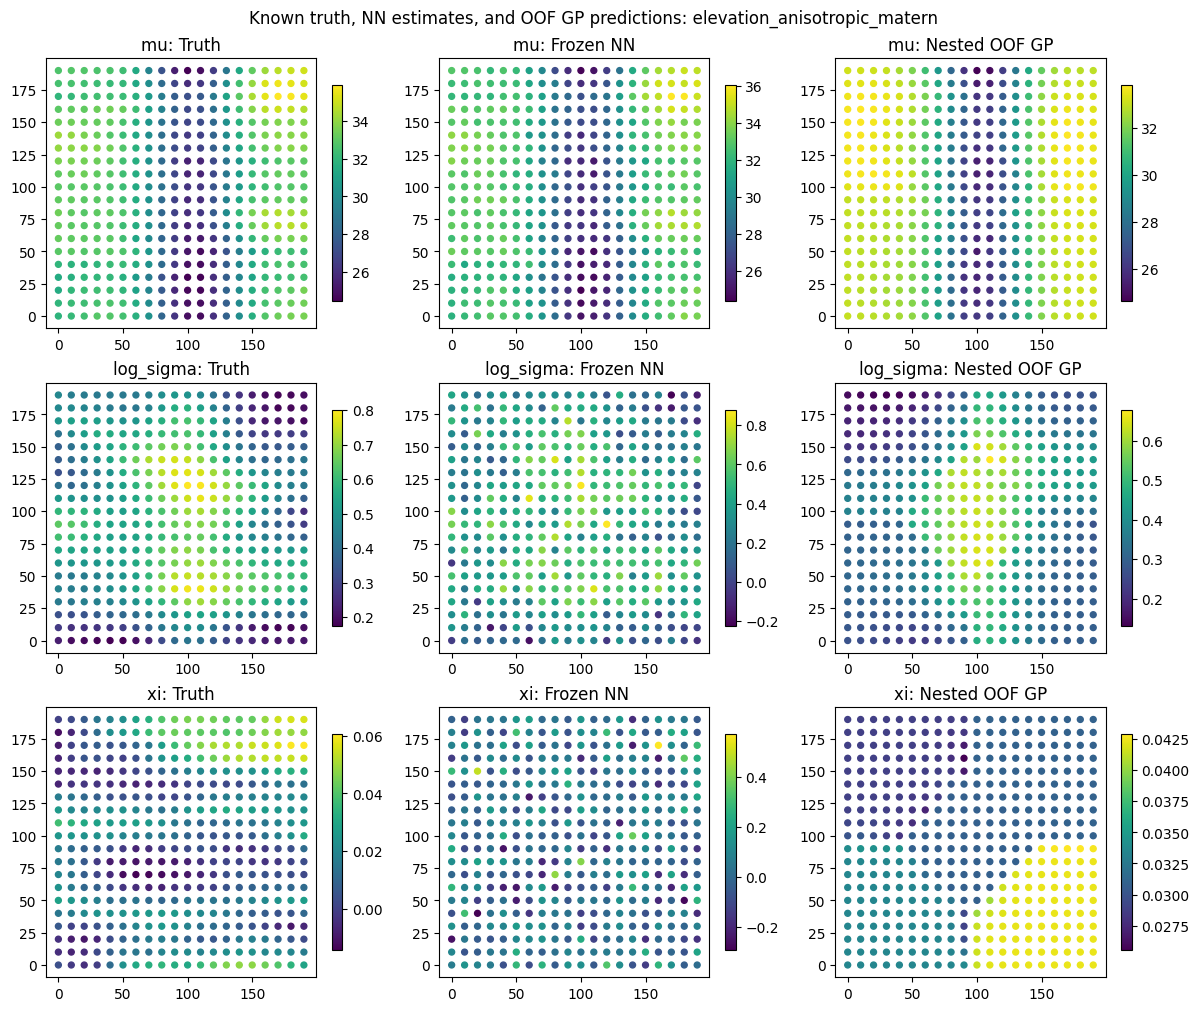

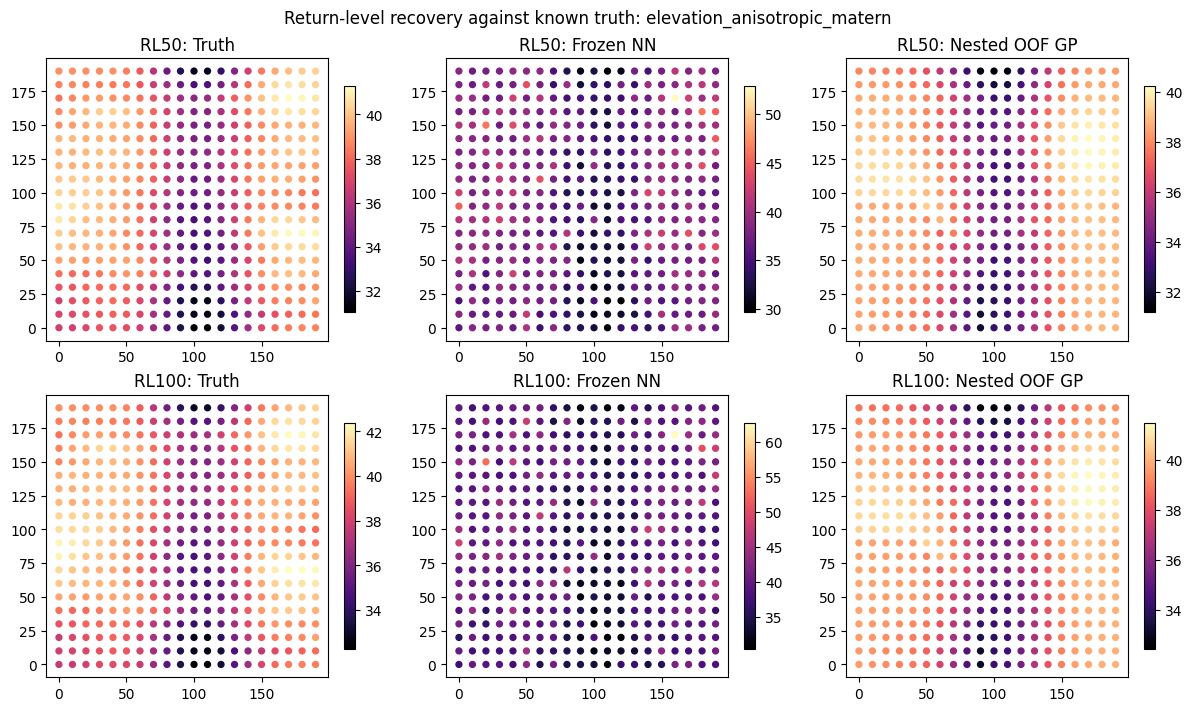

In [7]:
for scenario in SCENARIOS:
    display(plot_first_replicate_surfaces(results, scenario))
    display(plot_return_level_surfaces(results, scenario))
    plt.close('all')


## 8. 儲存可重製結果

輸出包含每次 replicate 的真值與 OOF 預測、各 outcome 指標、inner-CV 選模結果、selection frequency、設定檔與圖。正式分析應保留 seed 與完整 config。


grid                                          C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast ...
metrics                                       C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast ...
model_selections                              C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast ...
metric_summary                                C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast ...
selection_frequency                           C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast ...
config                                        C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast ...
stationary_rbf_parameters                     C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast ...
stationary_rbf_return_levels                  C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast ...
stationary_matern_parameters                  C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast ...
stationary_matern_return_levels               C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast ...
elevation_anisotropic_matern_parameters 

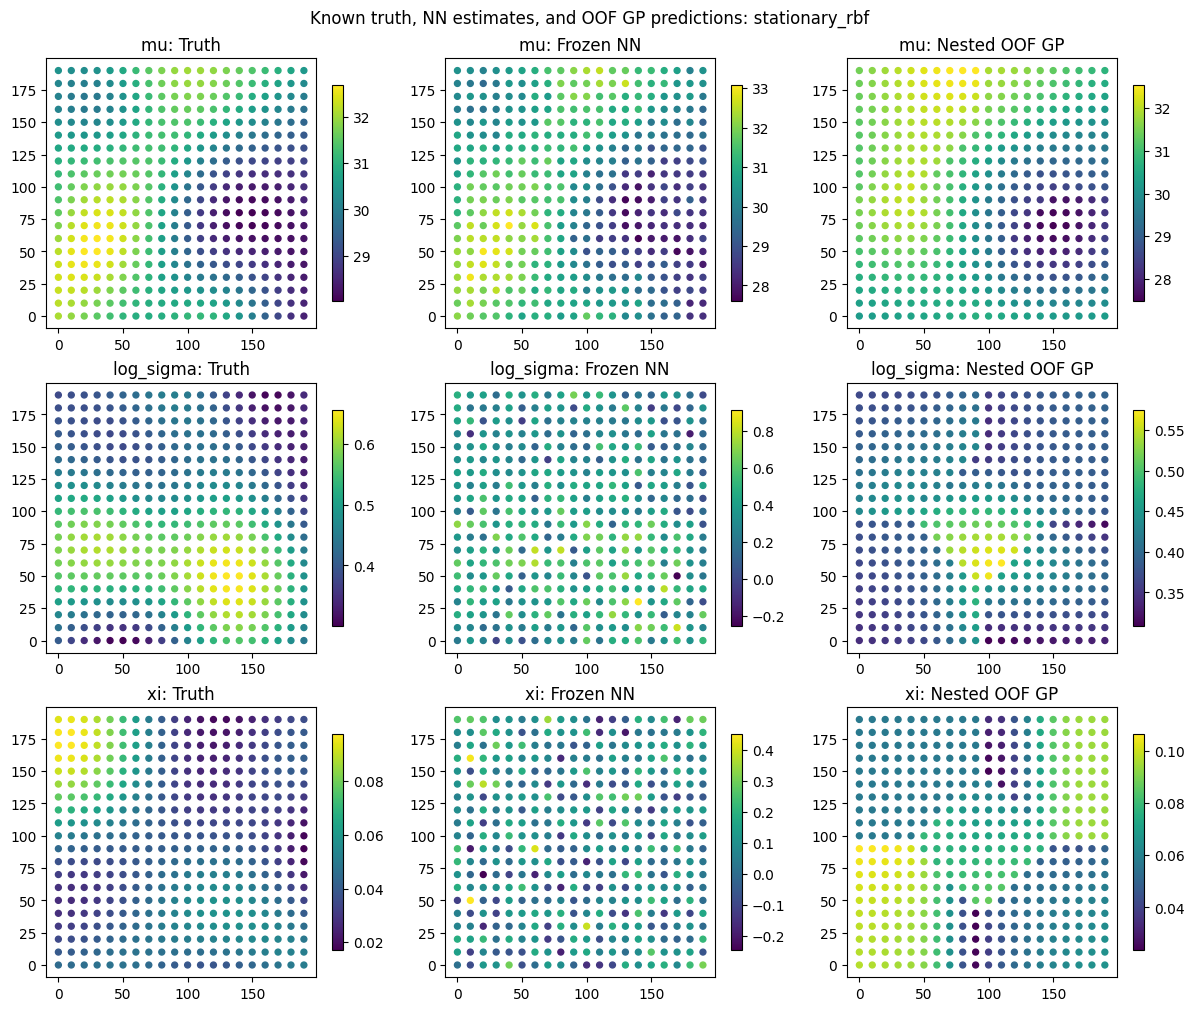

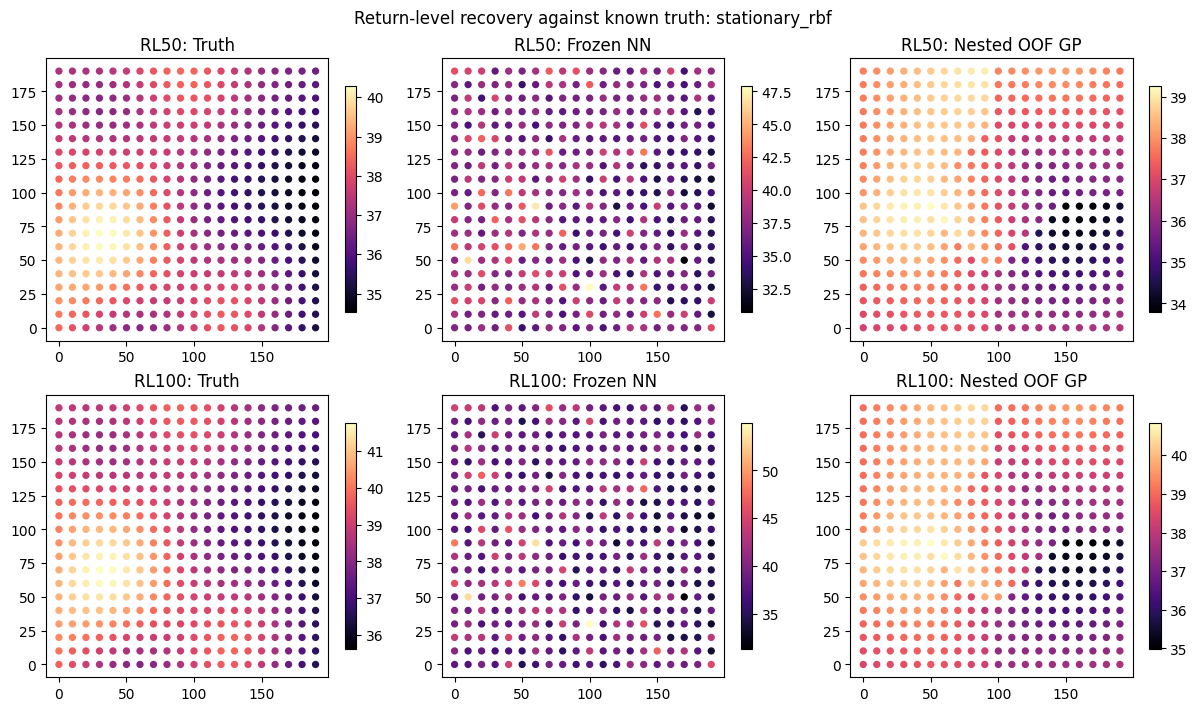

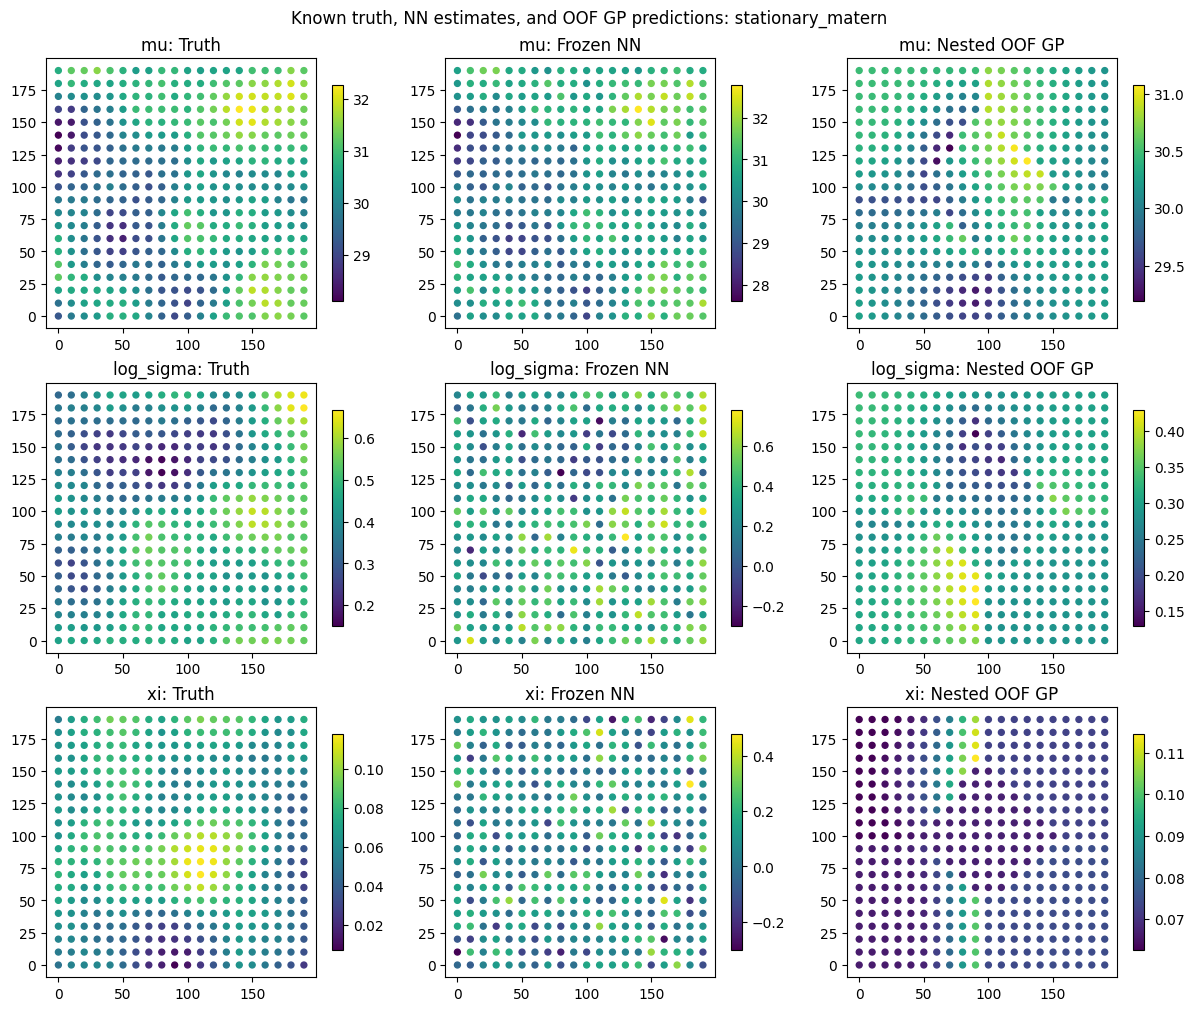

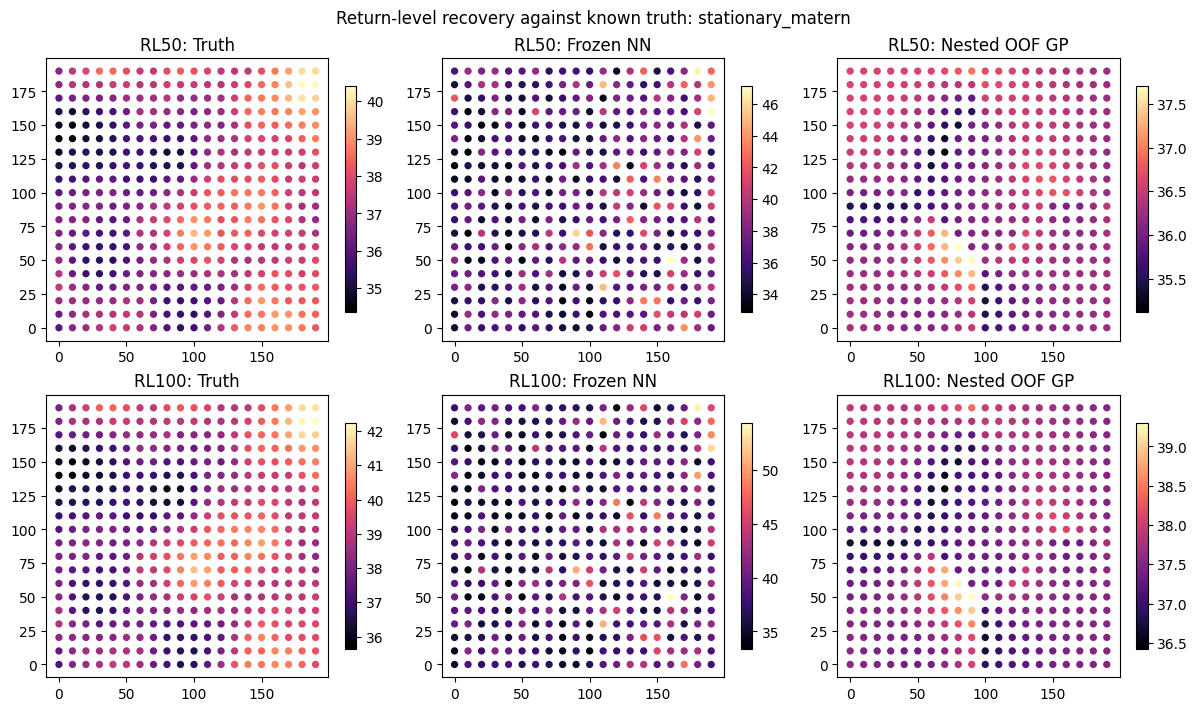

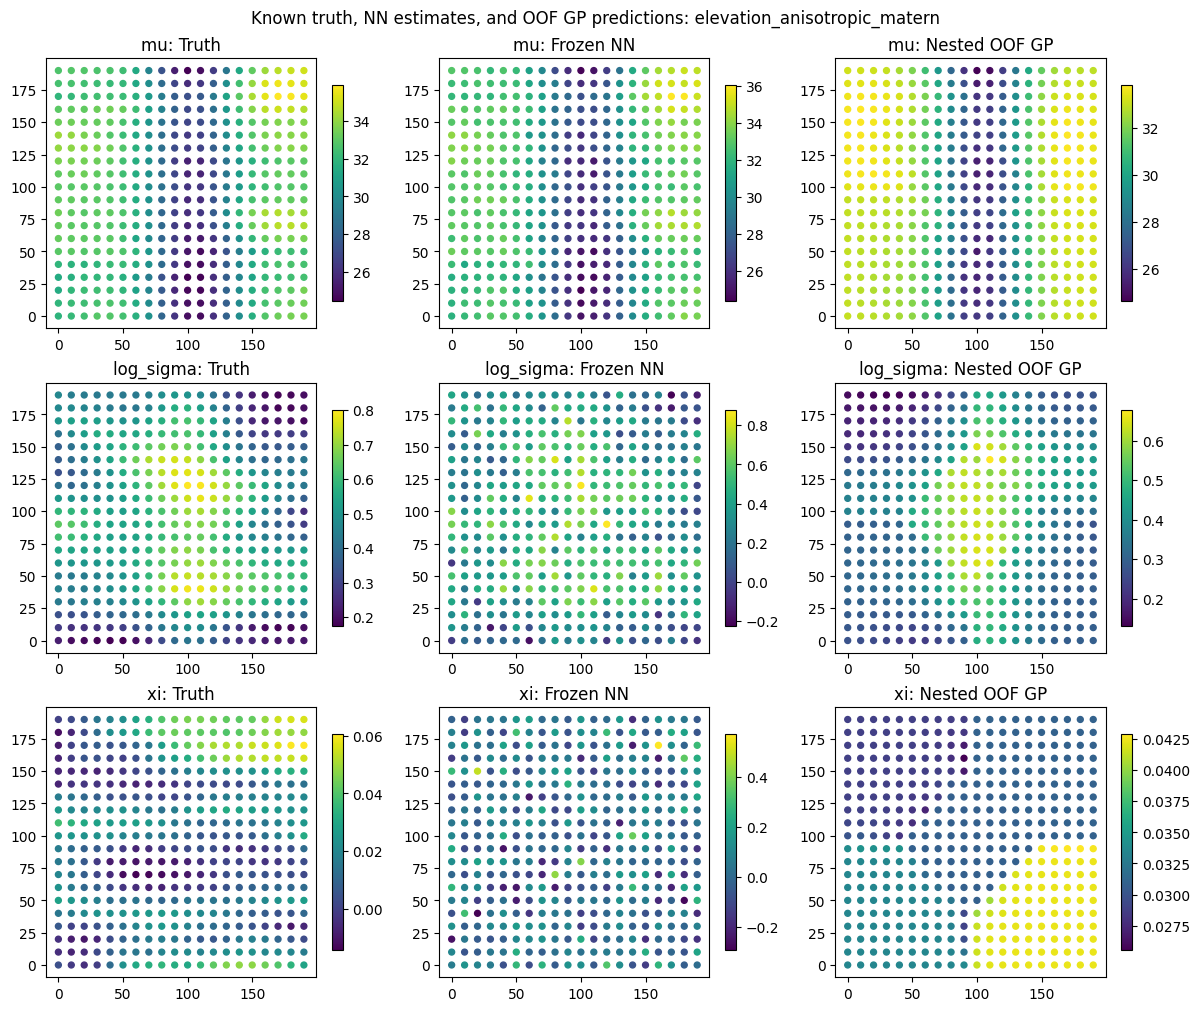

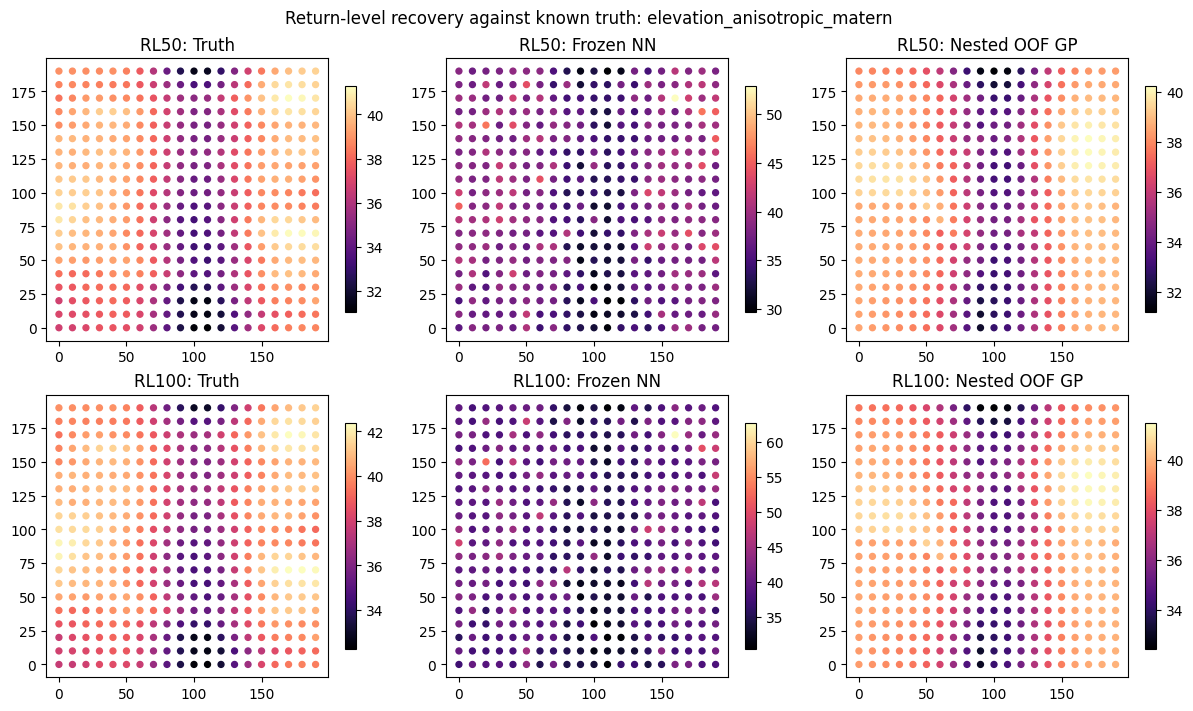

In [8]:
saved_paths = save_results(results, pilot_config)
pd.Series(saved_paths, name='path')
